In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report, roc_auc_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from imblearn.combine import SMOTEENN
import warnings
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

import joblib
import json


In [8]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///../../mlflow.db")   
mlflow.set_experiment("autoimmune-classification")

2026/09/17 00:52:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/17 00:52:58 INFO mlflow.store.db.utils: Updating database tables
2026/09/17 00:53:04 INFO mlflow.tracking.fluent: Experiment with name 'autoimmune-classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/hajar/Desktop/autoimmune-mlops-main/ml/notebooks/mlruns/1', creation_time=1789602784121, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789602784121, lifecycle_stage='active', name='autoimmune-classification', tags={}, trace_location=None, workspace='default'>

# Loading Cleaned Dataset

In [10]:
df = pd.read_csv("../../data/CleanedDataset.csv")
df=pd.DataFrame(df)
# pd.set_option('display.max_rows', None)
df.head()

,Age,Gender,Diagnosis,Sickness_Duration_Months,RBC_Count,Hemoglobin,Hematocrit,MCV,MCH,MCHC,...,Anti_SRP,Anti_desmoglein_3,anti_centromere,Anti_type_VII_collagen,C1_inhibitor,Anti_epidermal_basement_membrane_IgA,pANCA,Anti_tissue_transglutaminase,C4,Clinical_Symptoms_Count
0,62,1,0,41,4.75,13.37,43.11,101.91,28.41,34.98,...,0,0,0,0,0,0,0,0,2.228040,5
1,54,0,0,41,4.32,10.76,39.92,95.96,28.22,31.70,...,0,0,0,0,0,0,0,0,2.022216,7
2,34,1,0,86,4.42,11.91,38.38,80.56,28.40,35.21,...,0,0,0,0,0,0,0,0,2.074139,6
3,22,1,0,43,4.33,12.72,39.99,84.71,26.67,31.25,...,0,0,0,0,0,0,0,0,1.678122,4
4,20,0,0,50,3.99,11.07,43.58,89.87,30.64,32.77,...,0,0,0,0,0,0,0,0,2.177577,7


# Splitting Dataset

In [11]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.shape

(11049, 61)

In [13]:
X_test.shape

(2763, 61)

# Features selection

## Standardization 

In [14]:
num_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64'] and X[col].dropna().nunique() > 2]
other_cols = [col for col in X.columns if col not in num_cols]

In [15]:
# fitting standardization only on the training dataset and numerical features 
scaler_feature = StandardScaler()
X_train_scaled_frst = scaler_feature.fit_transform(X_train[num_cols])
# X_test_scaled = scaler.transform(X_test[num_cols])

# combining scaled numerical features with unscaled ones 
X_train_Final = pd.DataFrame(
    np.hstack([X_train_scaled_frst, X_train[other_cols].values]),
    columns = num_cols + other_cols
)


## RFE-CV

Optimal number of features: 23
Selected features: ['Age', 'Sickness_Duration_Months', 'RBC_Count', 'Hemoglobin', 'Hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW', 'Reticulocyte_Count', 'WBC_Count', 'Neutrophils', 'Lymphocytes', 'Monocytes', 'Eosinophils', 'Basophils', 'PLT_Count', 'MPV', 'Esbach', 'MBL_Level', 'ESR', 'C3', 'C4']


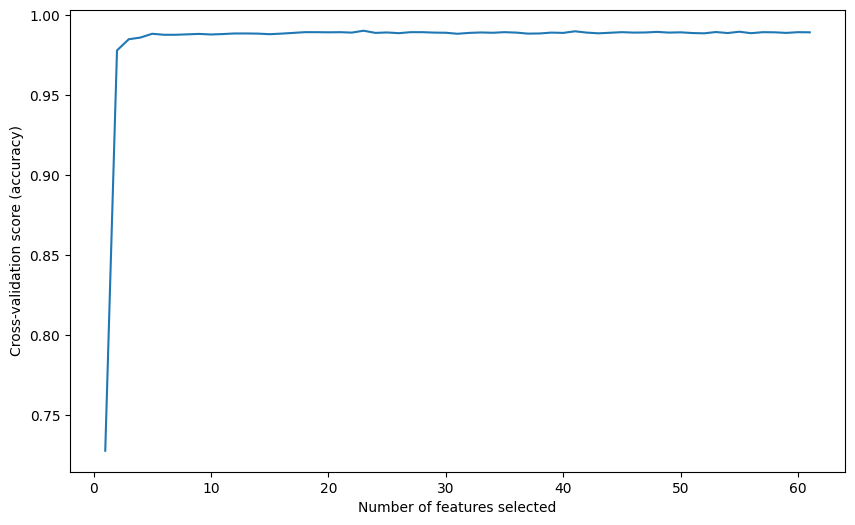

In [16]:
# Wrapper
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
rfecv = RFECV(estimator = estimator, step=1, cv=5, scoring='accuracy')
rfecv.fit(X_train_Final, y_train)

rfecv_features = X_train_Final.columns[rfecv.support_]
print("Optimal number of features:",len(rfecv_features))
print("Selected features:", list(rfecv_features))

joblib.dump(rfecv_features, '../features/rfecv_features.pkl')

rfecv_features = list(rfecv_features)
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (accuracy)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.show()

In [17]:
def scalling(X_train, X_test, features_set):
    finale_scaler = StandardScaler()

    num_cols_after = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64'] and X_train[col].dropna().nunique() > 2]
    other_cols_after = [col for col in X_train.columns if col not in num_cols_after]

    X_train_scaled = finale_scaler.fit_transform(X_train[num_cols_after])
    X_test_scaled = finale_scaler.transform(X_test[num_cols_after])


    # combining scaled numerical features with unscaled ones 
    X_train = pd.DataFrame(
        np.hstack([X_train_scaled, X_train[other_cols_after].values]),
        columns = num_cols_after + other_cols_after
    )

    X_test = pd.DataFrame(
        np.hstack([X_test_scaled, X_test[other_cols_after].values]),
        columns = num_cols_after + other_cols_after
    )
    
    joblib.dump(finale_scaler, f'../scalers/{features_set}_scaler.pkl')

    return finale_scaler, X_train, X_test


In [18]:
# RFE-cv
rfe_features_scaller, X_train_rfe_scalled, X_test_rfe_scalled = scalling(
    X_train[rfecv_features], X_test[rfecv_features], "rfe_features")

## Applying Balancing on training set only

In [19]:
smoteenn = SMOTEENN(random_state=42)

# RFE-cv
X_train_rfe_balanced, y_train_rfe_balanced = smoteenn.fit_resample(X_train_rfe_scalled, y_train)


print("Done balancing all the features sets !!!!")


Done balancing all the features sets !!!!


# Training

In [22]:

def training(X_test, y_test, X_train, y_train, model, modelname):
    with mlflow.start_run(run_name=model.__class__.__name__):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Cross-validation scores
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', error_score='raise')
        print(f"\n=== Cross-Validation Accuracy Scores ===\n{scores}")
        print(f"Moyenne : {scores.mean():.4f} | Écart-type : {scores.std():.4f}\n")

        # Generate learning curve data
        train_sizes, train_scores, test_scores = learning_curve(
            model, X_train, y_train, cv=cv, scoring='accuracy',
            train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
        )
        
        # Calculate mean and std for plotting
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        
        # Plot learning curve
        plt.figure(figsize=(10, 6))
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
        
        # Add shaded area for std deviation
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
        
        plt.title(f"Learning Curve ({model.__class__.__name__})")
        plt.xlabel("Training examples")
        plt.ylabel("Accuracy Score")
        plt.legend(loc="best")
        plt.grid()
        plt.show()
        
        # Fit model and get predictions
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        y_probs = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

        # Train metrics
        train_accuracy = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='weighted')
        
        # Test metrics
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        print("=== Training Metrics ===")
        print(f"Train Accuracy: {train_accuracy:.4f}")
        print(f"Train F1-score: {train_f1:.4f}\n")
        
        print("=== Test Metrics ===")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}")
        print(f"F1-score (weighted): {f1:.4f}")
        
        if y_probs is not None:
            roc_auc = roc_auc_score(y_test, y_probs, multi_class='ovr')
            print(f"ROC-AUC (OvR): {roc_auc:.4f}")
        
        print("\n=== Classification Report ===")
        print(classification_report(y_test, y_pred))
        
        print("\n=== Confusion Matrix ===")
        print(confusion_matrix(y_test, y_pred))


        #mlFlow
        mlflow.log_params(model.get_params())
        mlflow.log_metrics({
            "cv_accuracy_mean": scores.mean(),
            "test_accuracy": accuracy,
            "balanced_accuracy": balanced_acc,
            "f1_weighted": f1,
        })
        if y_probs is not None:
            mlflow.log_metric("roc_auc_ovr", roc_auc)
        mlflow.sklearn.log_model(
            model, "model",
            registered_model_name=f"autoimmune-{model.__class__.__name__}",
            skops_trusted_types=["sklearn.tree._tree.Tree"],
        )


        joblib.dump(model, modelname)

        return accuracy, balanced_acc, f1, roc_auc if y_probs is not None else None

## RFE

RF results: 
 

=== Cross-Validation Accuracy Scores ===
[0.99956897 0.99956897 1.         0.9987069  0.99913793]
Moyenne : 0.9994 | Écart-type : 0.0004



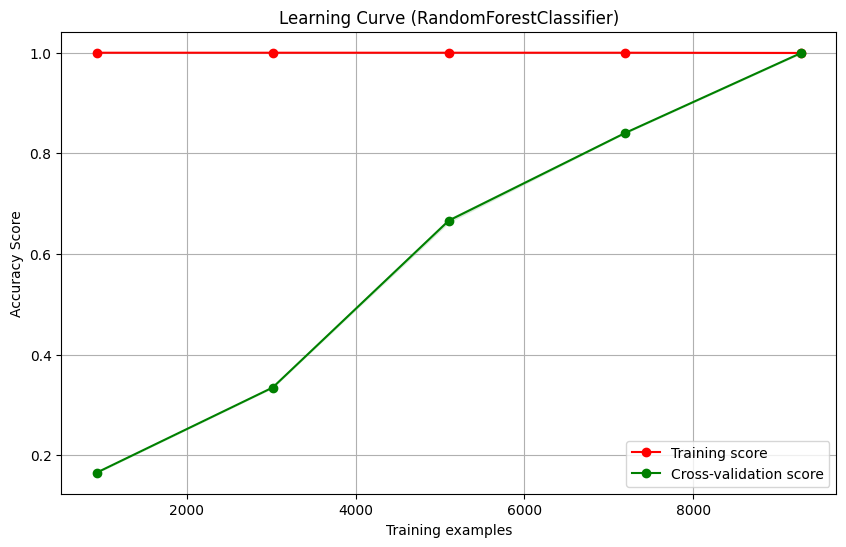

2026/09/17 01:11:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Training Metrics ===
Train Accuracy: 0.9996
Train F1-score: 0.9996

=== Test Metrics ===
Accuracy: 0.9895
Balanced Accuracy: 0.9901
F1-score (weighted): 0.9895
ROC-AUC (OvR): 0.9991

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       516
           1       1.00      1.00      1.00       441
           2       1.00      1.00      1.00       433
           3       0.98      1.00      0.99       472
           4       1.00      1.00      1.00       418
           5       0.99      0.95      0.97       483

    accuracy                           0.99      2763
   macro avg       0.99      0.99      0.99      2763
weighted avg       0.99      0.99      0.99      2763


=== Confusion Matrix ===
[[509   0   0   0   0   7]
 [  0 441   0   0   0   0]
 [  0   0 433   0   0   0]
 [  0   0   0 472   0   0]
 [  0   0   0   0 418   0]
 [ 11   2   0   9   0 461]]


Successfully registered model 'autoimmune-RandomForestClassifier'.
Created version '1' of model 'autoimmune-RandomForestClassifier'.


In [23]:
print('RF results: \n ')
accuracy_RF, balanced_acc_RF, f1_RF, roc_auc_RF = training(
    X_test_rfe_scalled, y_test,
    X_train_rfe_balanced, y_train_rfe_balanced,
    model = RandomForestClassifier(
                n_estimators=70, 
                max_depth=18,  
                min_samples_split = 10,
                random_state=42
            ),
    modelname= '../models/rfe_rf_model.pkl'
)


SVC results: 
 

=== Cross-Validation Accuracy Scores ===
[0.99956897 0.99956897 1.         0.99913793 0.99913793]
Moyenne : 0.9995 | Écart-type : 0.0003



c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hajar\AppData\

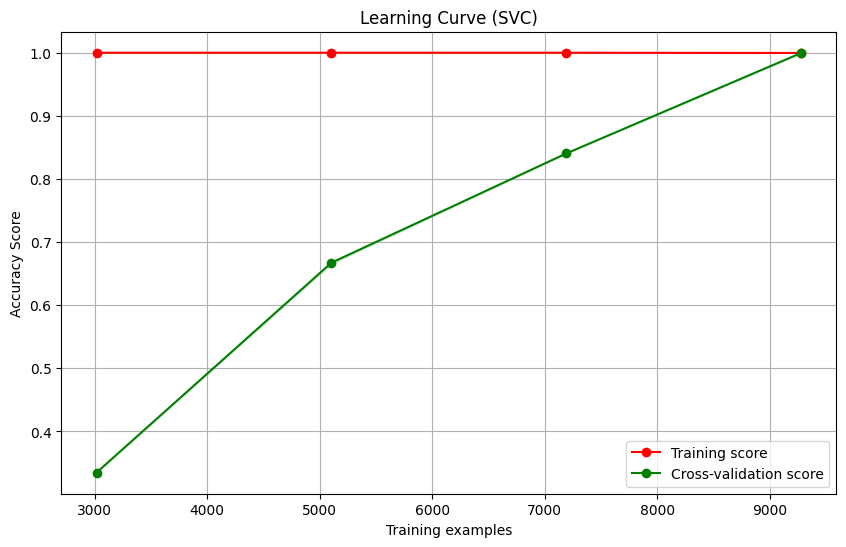

2026/09/17 01:15:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Training Metrics ===
Train Accuracy: 0.9996
Train F1-score: 0.9996

=== Test Metrics ===
Accuracy: 0.9873
Balanced Accuracy: 0.9881
F1-score (weighted): 0.9872

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       516
           1       0.99      1.00      0.99       441
           2       1.00      1.00      1.00       433
           3       0.98      1.00      0.99       472
           4       1.00      1.00      1.00       418
           5       0.98      0.94      0.96       483

    accuracy                           0.99      2763
   macro avg       0.99      0.99      0.99      2763
weighted avg       0.99      0.99      0.99      2763


=== Confusion Matrix ===
[[509   0   0   0   0   7]
 [  0 441   0   0   0   0]
 [  0   0 433   0   0   0]
 [  0   0   0 472   0   0]
 [  0   0   0   0 418   0]
 [ 13   5   0  10   0 455]]


Successfully registered model 'autoimmune-SVC'.
Created version '1' of model 'autoimmune-SVC'.


In [24]:
print('SVC results: \n ')
accuracy_SVC, balanced_acc_SVC, f1_SVC, roc_auc_SVC = training(
    X_test_rfe_scalled, y_test,
    X_train_rfe_balanced, y_train_rfe_balanced,
    model =  SVC(
                C=5, 
                kernel='rbf', 
                gamma=0.05, 
                class_weight='balanced', 
                random_state=42
            ),
    modelname= '../models/rfe_svc_model.pkl'
)

c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hajar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\

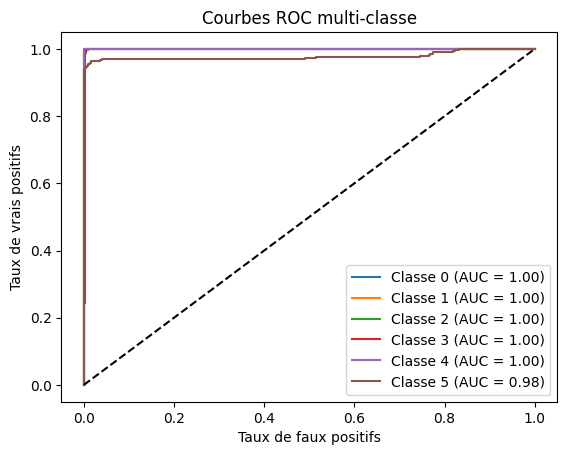

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay
import numpy as np

# Binarisation des labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5])
n_classes = y_test_bin.shape[1]

# Entraînement One-vs-Rest
model = OneVsRestClassifier(SVC(C=1, kernel='poly', gamma=0.1, 
                class_weight='balanced', probability=True, random_state=42))

model.fit(X_train_rfe_balanced, y_train_rfe_balanced)
y_score = model.predict_proba(X_test_rfe_scalled)

# Courbe ROC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Affichage
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Classe {i} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Courbes ROC multi-classe")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend()
plt.show()


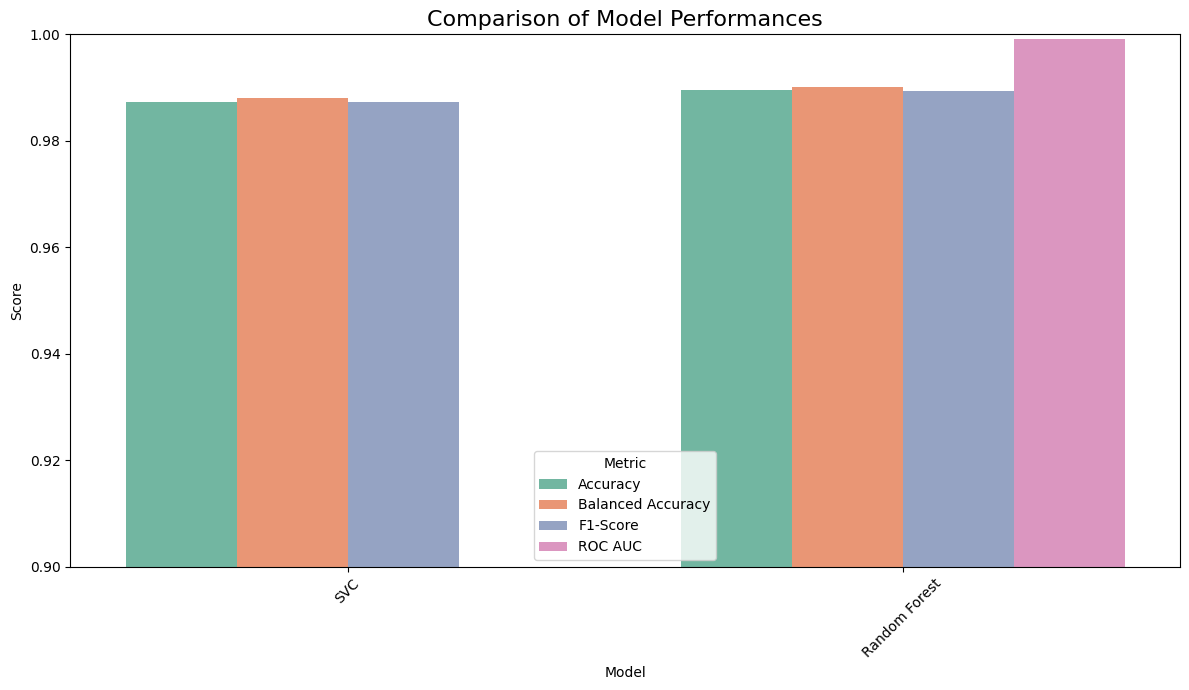

In [26]:

data = {
    'Model': [
        'SVC', 'Random Forest'
              ] * 4,
    "Score": [
         accuracy_SVC, accuracy_RF,
         balanced_acc_SVC, balanced_acc_RF,
         f1_SVC, f1_RF,
         roc_auc_SVC, roc_auc_RF
    ],
    "Metric": (
        ["Accuracy"] * 2 +
        ["Balanced Accuracy"] * 2 +
        ["F1-Score"] * 2 +
        ["ROC AUC"] * 2
    )
}

data = pd.DataFrame(data)

plt.figure(figsize=(12, 7))
sns.barplot(x="Model", y="Score", hue="Metric", data=data, palette="Set2")
plt.ylim(0.9, 1.0) 
plt.xticks(rotation=45)
plt.title('Comparison of Model Performances', fontsize=16)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()
